In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python is working!")

Python is working!


In [2]:
print("Pediatric Cancer Research Analysis")
print("This project looks at pediatric cancer disease burden compared to research attention.")

Pediatric Cancer Research Analysis
This project looks at pediatric cancer disease burden compared to research attention.


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/SAMPLE_INFO.tsv", sep="\t")

df.head()

,file_type,subject_name,sample_name,sample_type,file_size,attr_age_at_diagnosis,attr_diagnosis,attr_diagnosis_group,attr_ethnicity,attr_germline_sample,...,sj_embargo_date,sj_long_disease_name,sj_pipeline_name,sj_pipeline_version,sj_pmid_accessions,sj_pub_accessions,sj_publication_titles,target_name,tissue_type,file_id
0,BAM,SJ045720,SJNORM045720_G1,Germline,5102185802,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fq40j9pPF37VKqPPpg7vbj
1,BAM,SJ045726,SJNORM045726_G1,Germline,7934104,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fpzx09gxqBZ7VYGFVYXP03
2,BAM,SJ045711,SJNORM045711_G1,Germline,7204704,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fpzzj9pV6XbVZKPKvXvgpQ
3,BAM,SJ045724,SJNORM045724_G1,Germline,6987427744,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fpv8893Gqkf62kPKk6BVb4
4,BAM,SJ045716,SJNORM045716_G1,Germline,7323544,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fq1009q68xf8ZzJGV242Q1


In [4]:
# Check for missing values
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Percent Missing": missing_percent
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Percent Missing
attr_subtype_biomarkers,8125,5.121272


In [5]:
print("Number of duplicate rows:", df.duplicated().sum())
df.info()

Number of duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 158652 entries, 0 to 158651
Data columns (total 44 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   file_type                        158652 non-null  str  
 1   subject_name                     158652 non-null  str  
 2   sample_name                      158652 non-null  str  
 3   sample_type                      158652 non-null  str  
 4   file_size                        158652 non-null  int64
 5   attr_age_at_diagnosis            158652 non-null  str  
 6   attr_diagnosis                   158652 non-null  str  
 7   attr_diagnosis_group             158652 non-null  str  
 8   attr_ethnicity                   158652 non-null  str  
 9   attr_germline_sample             158652 non-null  str  
 10  attr_inferred_strandedness       158652 non-null  str  
 11  attr_lab_strandedness            158652 non-null  str  
 12  attr_library_

### Cleaning Decisions

There were no duplicate rows in the dataset. Most columns did not contain missing values. The `attr_subtype_biomarkers` column had some missing values, so I kept them as missing rather than removing those rows because the missing information may still be useful for analysis. I also checked the data types and category values for inconsistencies.

In [6]:
cancer_counts = df["ped_cancer_diagnosis_category"].value_counts()

cancer_counts.head(15)

ped_cancer_diagnosis_category
Not Applicable                         96022
Lymphoblastic Leukemia                 16614
Myeloid Leukemia                        8491
High-grade Glioma                       4898
Medulloblastoma                         4016
Neuroblastoma                           3100
Ependymoma                              2489
Renal Tumors                            2474
Rhabdomyosarcoma                        2445
Osteosarcoma                            2341
Soft Tissue Tumors                      2007
Other Solid Tumors                      1879
Retinoblastoma                          1818
Endocrine and Neuroendocrine Tumors     1613
Glioneuronal and Neuronal Tumors        1132
Name: count, dtype: int64

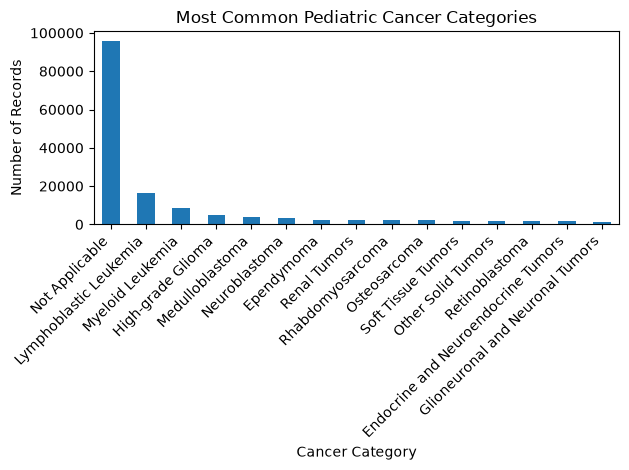

In [7]:
import matplotlib.pyplot as plt

cancer_counts.head(15).plot(kind="bar")

plt.title("Most Common Pediatric Cancer Categories")
plt.xlabel("Cancer Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

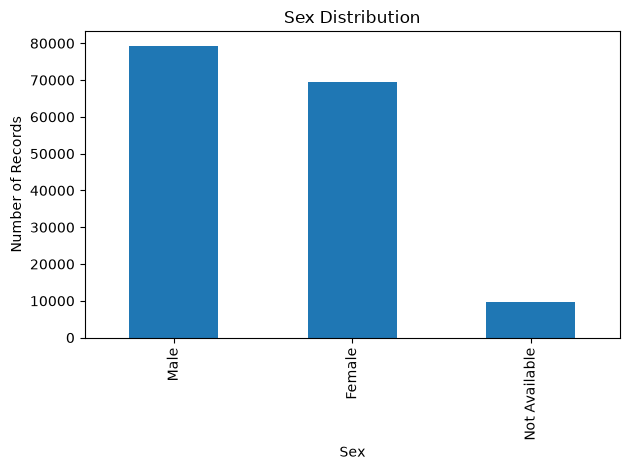

In [8]:
df["attr_sex"].value_counts().plot(kind="bar")

plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

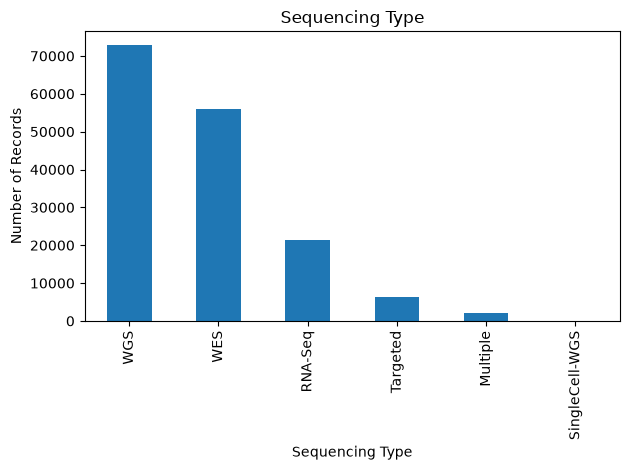

In [9]:
df["sequencing_type"].value_counts().plot(kind="bar")

plt.title("Sequencing Type")
plt.xlabel("Sequencing Type")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

The dataset contains 158,652 records and 44 variables. I found that the dataset includes several different pediatric cancer categories, with some categories having many more records than others. The dataset also contains information about patient characteristics, cancer diagnosis, sample type, and sequencing type. One concern is that a large number of records are labeled “Not Applicable” for some cancer classification variables, so I will need to decide how to handle these records when comparing cancer types. I am hoping to have more data by next week, as I am still wiating to gain access to several SEER databases. 